In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import json
# Path to the parquet file
file_path_1 = "saved_analysis_states/model_evaluation_mart.parquet"
file_path_2 = "saved_analysis_states/state_table.parquet"
file_path_3 = "saved_analysis_states/data_splits.json"

# Load parquet
df_eval = pd.read_parquet(file_path_1)
df_states = pd.read_parquet(file_path_2)

with open(file_path_3, "r") as f:
    splits = json.load(f)

print(df_eval.columns)
print(df_states.columns)
print(splits.keys())

Index(['customer_id', 'future_revenue', 'split', 'snapshot_date',
       'holdout_days', 'pred_lightgbm', 'p_active', 'pred_frequency',
       'pred_aov', 'pred_rfm', 'pred_bgnbd', 'pred_pareto', 'error_lightgbm',
       'ae_lightgbm', 'se_lightgbm', 'rank_lightgbm', 'error_rfm', 'ae_rfm',
       'se_rfm', 'rank_rfm', 'error_bgnbd', 'ae_bgnbd', 'se_bgnbd',
       'rank_bgnbd', 'error_pareto', 'ae_pareto', 'se_pareto', 'rank_pareto'],
      dtype='object')
Index(['customer_id', 'snapshot_date', 'first_purchase_date',
       'last_purchase_date', 'frequency', 'repeat_frequency', 'total_revenue',
       'avg_order_value', 'std_order_value', 'tenure_days', 'recency_days',
       'avg_gap_days', 'std_gap_days', 'max_gap_days', 'unique_products_total',
       'avg_unique_products', 'orders_last_30d', 'revenue_last_30d', 'is_new',
       'is_dormant', 'purchase_regularity', 'revenue_volatility', 'country',
       'future_purchase_count', 'future_revenue', 'future_avg_order_value',
       'had

In [3]:
CLUSTERING_FEATURES = [
    # Purchase Frequency
    "frequency", "repeat_frequency",
    # Monetary Value
    "total_revenue", "avg_order_value", "std_order_value",
    # Customer Age
    "tenure_days",
    # Recency
    "recency_days",
    # Purchase Timing
    "avg_gap_days", "std_gap_days", "max_gap_days",
    # Product Breadth
    "unique_products_total", "avg_unique_products",
    # Recent Activity
    "orders_last_30d", "revenue_last_30d",
    # Behavioral Flags
    "is_new", "is_dormant",
    # Stability Metrics
    "purchase_regularity", "revenue_volatility"
]
df_cluster = df_states[["customer_id", "country"] + CLUSTERING_FEATURES].copy()

print(f"Clustering dataset shape: {df_cluster.shape}")
print(f"\nFeatures used for clustering ({len(CLUSTERING_FEATURES)}):")
print(CLUSTERING_FEATURES)
print(f"\nMissing values per feature:")
print(df_cluster[CLUSTERING_FEATURES].isnull().sum())
print(f"\nSample statistics:")
print(df_cluster[CLUSTERING_FEATURES].describe().round(2))

Clustering dataset shape: (4716, 20)

Features used for clustering (18):
['frequency', 'repeat_frequency', 'total_revenue', 'avg_order_value', 'std_order_value', 'tenure_days', 'recency_days', 'avg_gap_days', 'std_gap_days', 'max_gap_days', 'unique_products_total', 'avg_unique_products', 'orders_last_30d', 'revenue_last_30d', 'is_new', 'is_dormant', 'purchase_regularity', 'revenue_volatility']

Missing values per feature:
frequency                   0
repeat_frequency            0
total_revenue               0
avg_order_value             0
std_order_value             0
tenure_days                 0
recency_days                0
avg_gap_days             1560
std_gap_days                0
max_gap_days                0
unique_products_total       0
avg_unique_products         0
orders_last_30d             0
revenue_last_30d            0
is_new                      0
is_dormant                  0
purchase_regularity      1560
revenue_volatility          0
dtype: int64

Sample statistics:
 

Boolean columns cast to int: ['is_new', 'is_dormant']

=== Feature Statistics ===
        frequency  repeat_frequency  total_revenue  avg_order_value  \
count     4716.00           4716.00        4716.00          4716.00   
mean         4.91              3.91        2251.02           371.82   
std          9.34              9.34       10030.41           511.51   
min          1.00              0.00           2.95             2.95   
25%          1.00              0.00         306.09           173.87   
50%          2.00              1.00         710.79           280.02   
75%          5.00              4.00        1826.78           414.67   
max        235.00            234.00      366609.15         11880.84   
skew        10.43             10.43          23.13            11.73   
median       2.00              1.00         710.79           280.02   

        std_order_value  tenure_days  recency_days  avg_gap_days  \
count           4716.00      4716.00       4716.00       3156.00   


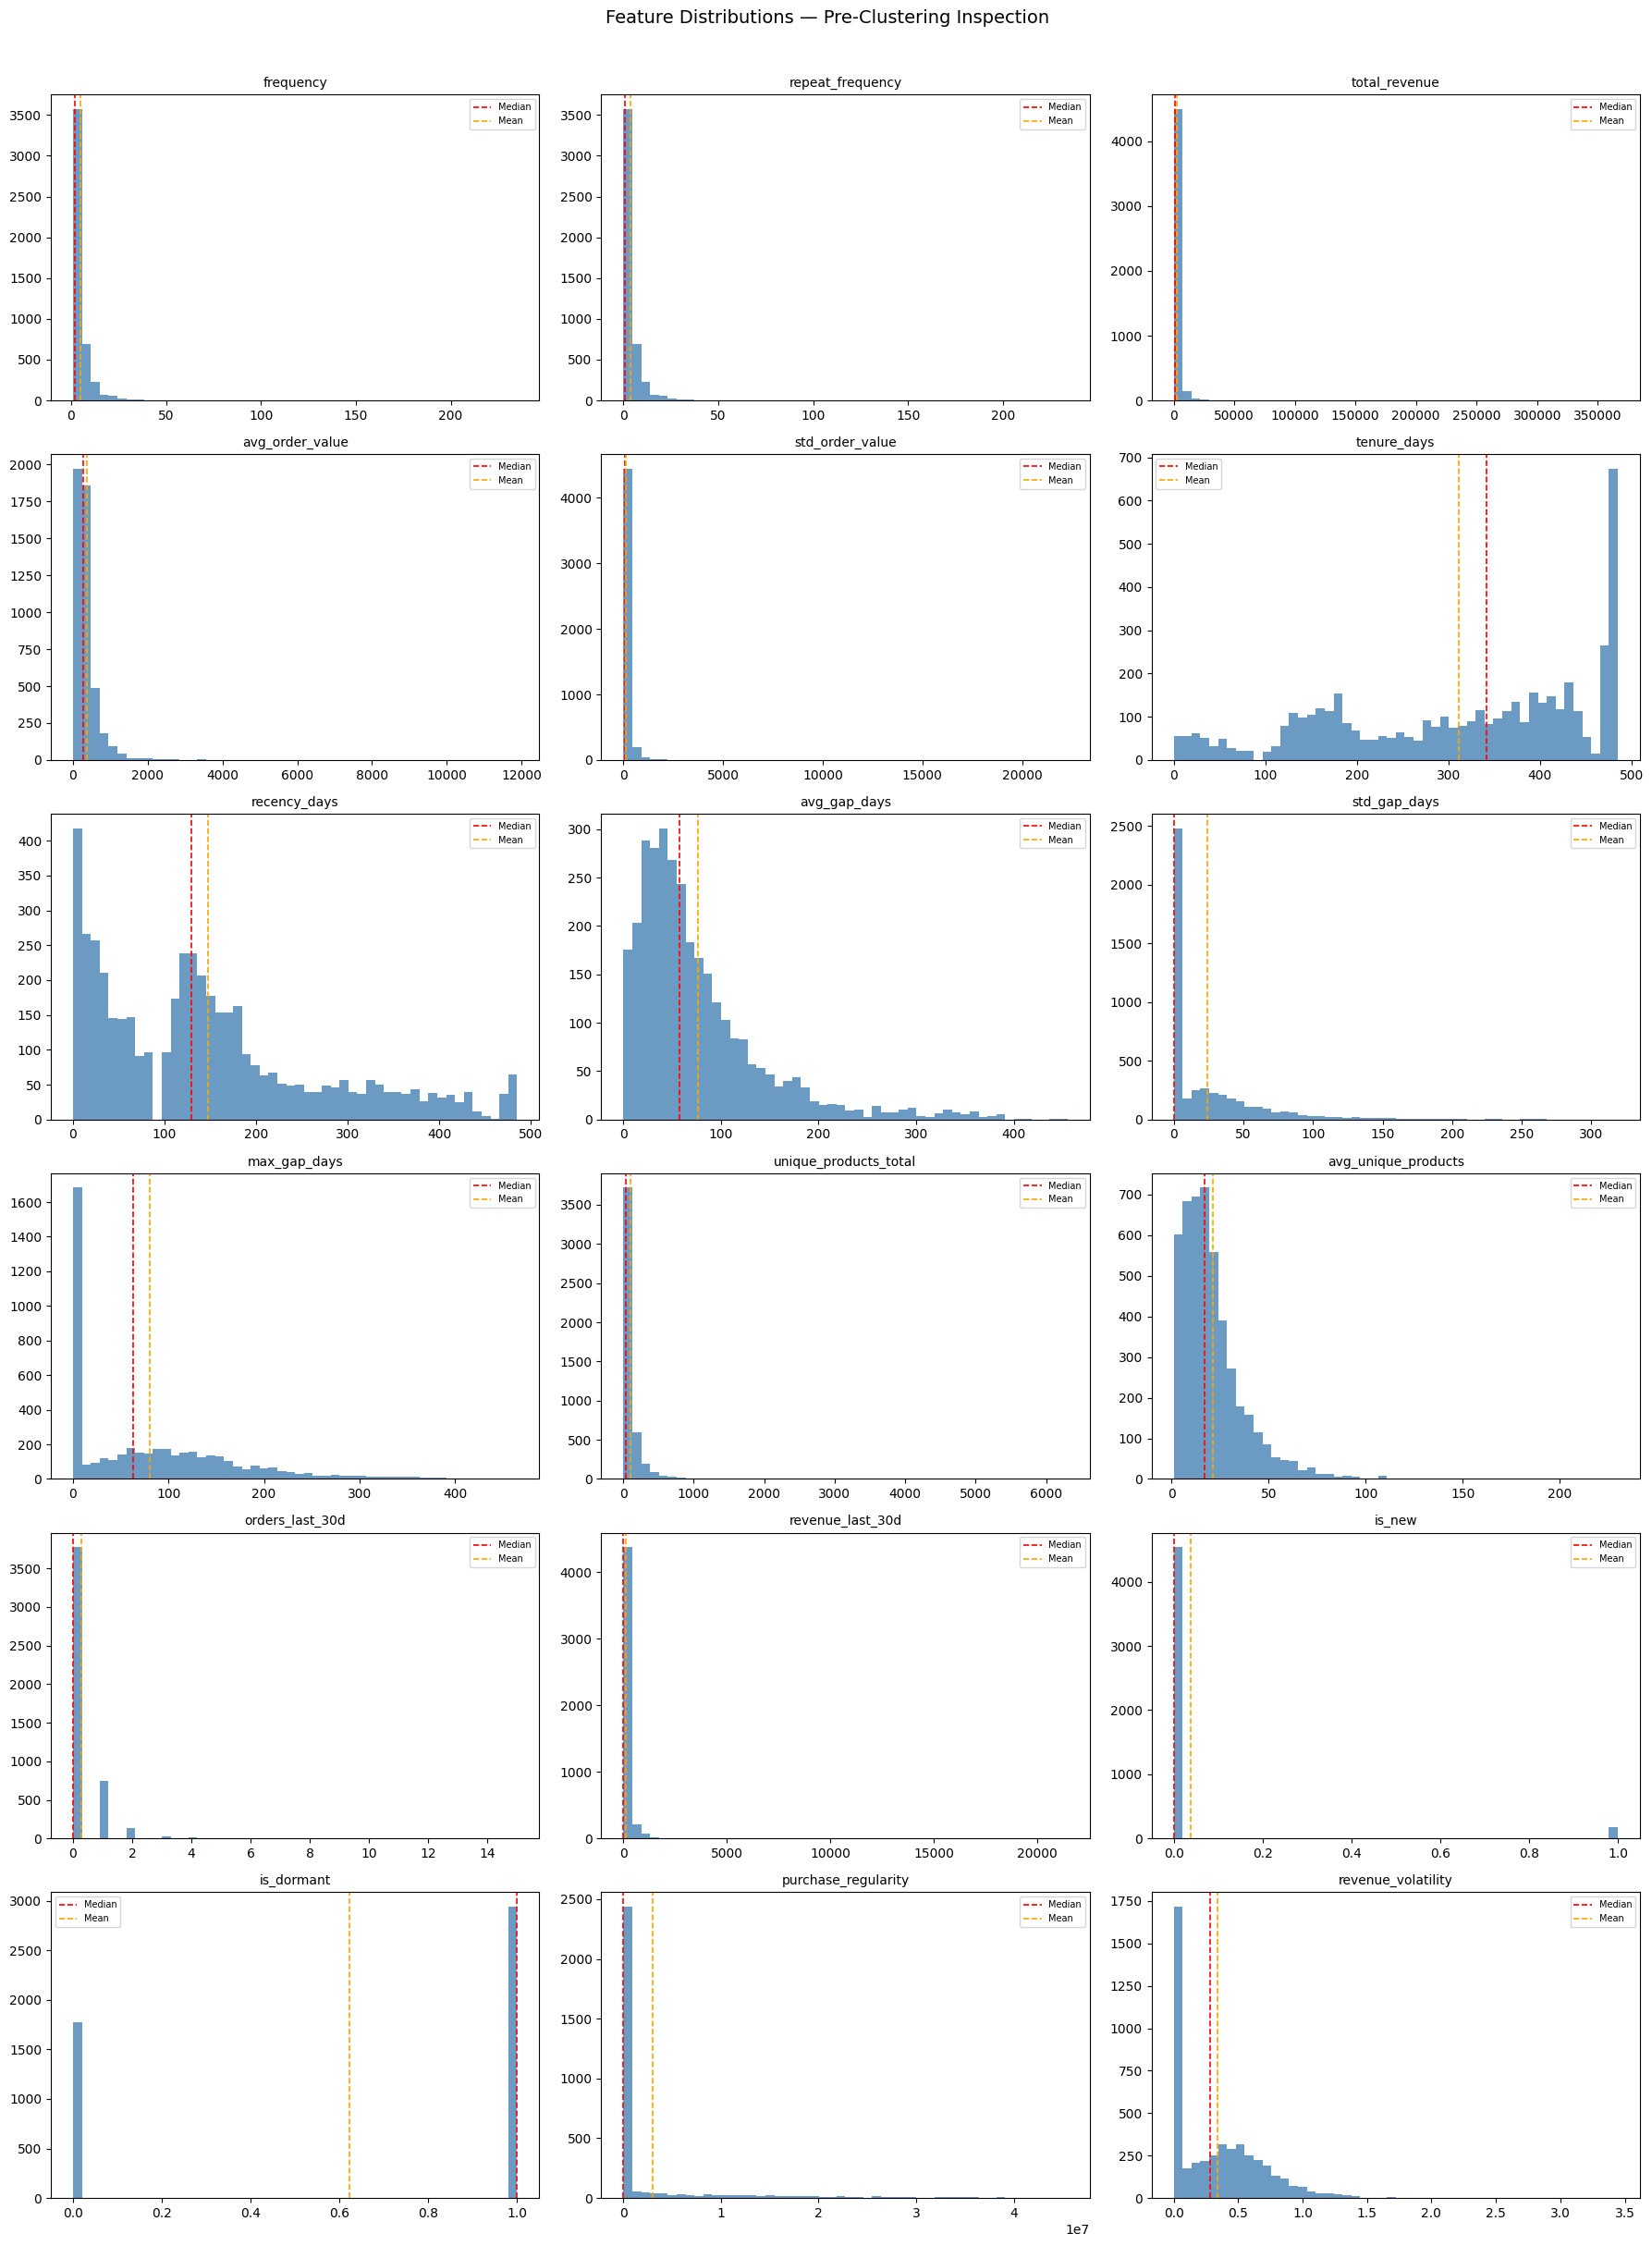


=== Percentile Breakdown for Highly Skewed Features (|skew| > 2) ===
Highly skewed features: ['frequency', 'repeat_frequency', 'total_revenue', 'avg_order_value', 'std_order_value', 'std_gap_days', 'unique_products_total', 'avg_unique_products', 'orders_last_30d', 'revenue_last_30d', 'is_new', 'purchase_regularity']

  frequency
    p50   : 2.0000
    p75   : 5.0000
    p90   : 10.0000
    p95   : 15.0000
    p99   : 34.8500
    p99.9 : 133.5700
    p100  : 235.0000

  repeat_frequency
    p50   : 1.0000
    p75   : 4.0000
    p90   : 9.0000
    p95   : 14.0000
    p99   : 33.8500
    p99.9 : 132.5700
    p100  : 234.0000

  total_revenue
    p50   : 710.7900
    p75   : 1826.7775
    p90   : 4158.8200
    p95   : 7000.6575
    p99   : 22875.8220
    p99.9 : 118862.3682
    p100  : 366609.1500

  avg_order_value
    p50   : 280.0250
    p75   : 414.6700
    p90   : 660.0100
    p95   : 910.0200
    p99   : 1952.5015
    p99.9 : 6858.6992
    p100  : 11880.8400

  std_order_value
    p

In [4]:
# Diagnostic — Feature Distribution Inspection 

import matplotlib.pyplot as plt
import numpy as np

# --- Fix: cast boolean columns to int for numeric operations ---
df_inspect = df_cluster.copy()
bool_cols = df_inspect[CLUSTERING_FEATURES].select_dtypes(include="bool").columns.tolist()
print(f"Boolean columns cast to int: {bool_cols}")
df_inspect[bool_cols] = df_inspect[bool_cols].astype(int)

# --- 1. Basic statistics with skewness ---
print("\n=== Feature Statistics ===")
stats = df_inspect[CLUSTERING_FEATURES].describe().round(2)
stats.loc["skew"]   = df_inspect[CLUSTERING_FEATURES].skew().round(2)
stats.loc["median"] = df_inspect[CLUSTERING_FEATURES].median().round(2)
print(stats)

# --- 2. Outlier check using 3x IQR ---
print("\n=== Outlier Check (values beyond 3 IQR from median) ===")
for feat in CLUSTERING_FEATURES:
    col = df_inspect[feat].dropna()
    Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((col < Q1 - 3 * IQR) | (col > Q3 + 3 * IQR)).sum()
    pct = outliers / len(col) * 100
    print(f"  {feat:<30} outliers: {outliers:>5} ({pct:.2f}%)")

# --- 3. Distribution plots ---
fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.flatten()

for i, feat in enumerate(CLUSTERING_FEATURES):
    col = df_inspect[feat].dropna()
    axes[i].hist(col, bins=50, color="steelblue", edgecolor="none", alpha=0.8)
    axes[i].axvline(col.median(), color="red",    linestyle="--", linewidth=1.2, label="Median")
    axes[i].axvline(col.mean(),   color="orange", linestyle="--", linewidth=1.2, label="Mean")
    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=7)

for j in range(len(CLUSTERING_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions — Pre-Clustering Inspection", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("saved_analysis_states/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 4. Percentile breakdown for highly skewed features ---
print("\n=== Percentile Breakdown for Highly Skewed Features (|skew| > 2) ===")
skewed_feats = df_inspect[CLUSTERING_FEATURES].skew()
skewed_feats = skewed_feats[skewed_feats.abs() > 2].index.tolist()
print(f"Highly skewed features: {skewed_feats}")

for feat in skewed_feats:
    col = df_inspect[feat].dropna()
    print(f"\n  {feat}")
    for p in [50, 75, 90, 95, 99, 99.9, 100]:
        print(f"    p{p:<5}: {np.percentile(col, p):.4f}")

In [5]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# --- Phase 2 ---
train_ids = set(splits["train_customers"])
val_ids   = set(splits["val_customers"])
test_ids  = set(splits["test_customers"])

df_train = df_cluster[df_cluster["customer_id"].isin(train_ids)].copy()
df_val   = df_cluster[df_cluster["customer_id"].isin(val_ids)].copy()
df_test  = df_cluster[df_cluster["customer_id"].isin(test_ids)].copy()

print(f"Total customers in dataset : {len(df_cluster)}")
print(f"Train customers            : {len(df_train)}")
print(f"Val customers (withheld)   : {len(df_val)}")
print(f"Test customers (withheld)  : {len(df_test)}")

# --- Boolean fix ---
for df in [df_train, df_val, df_test]:
    bool_cols = df[CLUSTERING_FEATURES].select_dtypes(include="bool").columns.tolist()
    df[bool_cols] = df[bool_cols].astype(int)

# --- Drop purchase_regularity (data artefact — p90 jumps to 12M) ---
CLUSTERING_FEATURES_CLEAN = [f for f in CLUSTERING_FEATURES if f != "purchase_regularity"]
print(f"\nDropped: purchase_regularity")
print(f"Remaining features ({len(CLUSTERING_FEATURES_CLEAN)}): {CLUSTERING_FEATURES_CLEAN}")

# --- NaN Imputation (train medians only) ---
train_medians = df_train[CLUSTERING_FEATURES_CLEAN].median()
for df in [df_train, df_val, df_test]:
    df[CLUSTERING_FEATURES_CLEAN] = df[CLUSTERING_FEATURES_CLEAN].fillna(train_medians)

print(f"\nNaN counts after imputation:")
print(f"  Train : {df_train[CLUSTERING_FEATURES_CLEAN].isnull().sum().sum()}")
print(f"  Val   : {df_val[CLUSTERING_FEATURES_CLEAN].isnull().sum().sum()}")
print(f"  Test  : {df_test[CLUSTERING_FEATURES_CLEAN].isnull().sum().sum()}")

# --- Log Transform (log1p — safe for zeros) ---
LOG_TRANSFORM_FEATURES = [
    "frequency", "repeat_frequency",
    "total_revenue", "avg_order_value", "std_order_value",
    "unique_products_total", "avg_unique_products",
    "orders_last_30d", "revenue_last_30d",
    "std_gap_days"
]

for df in [df_train, df_val, df_test]:
    for feat in LOG_TRANSFORM_FEATURES:
        df[feat] = np.log1p(df[feat])

print(f"\nLog1p transform applied to: {LOG_TRANSFORM_FEATURES}")

# --- Verify skew after transform ---
print(f"\nSkewness after log transform (train):")
for feat in LOG_TRANSFORM_FEATURES:
    print(f"  {feat:<30}: {df_train[feat].skew():.2f}")

# --- Phase 3: Scale ---
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(df_train[CLUSTERING_FEATURES_CLEAN])
X_val_scaled   = scaler.transform(df_val[CLUSTERING_FEATURES_CLEAN])
X_test_scaled  = scaler.transform(df_test[CLUSTERING_FEATURES_CLEAN])

print(f"\nScaled X_train shape : {X_train_scaled.shape}")
print(f"Scaled X_val shape   : {X_val_scaled.shape}")
print(f"Scaled X_test shape  : {X_test_scaled.shape}")

print(f"\nPost-scaling train feature means (should be ≈ 0):")
print(dict(zip(CLUSTERING_FEATURES_CLEAN, X_train_scaled.mean(axis=0).round(3))))
print(f"\nPost-scaling train feature stds (should be ≈ 1):")
print(dict(zip(CLUSTERING_FEATURES_CLEAN, X_train_scaled.std(axis=0).round(3))))

Total customers in dataset : 4716
Train customers            : 2829
Val customers (withheld)   : 943
Test customers (withheld)  : 944

Dropped: purchase_regularity
Remaining features (17): ['frequency', 'repeat_frequency', 'total_revenue', 'avg_order_value', 'std_order_value', 'tenure_days', 'recency_days', 'avg_gap_days', 'std_gap_days', 'max_gap_days', 'unique_products_total', 'avg_unique_products', 'orders_last_30d', 'revenue_last_30d', 'is_new', 'is_dormant', 'revenue_volatility']

NaN counts after imputation:
  Train : 0
  Val   : 0
  Test  : 0

Log1p transform applied to: ['frequency', 'repeat_frequency', 'total_revenue', 'avg_order_value', 'std_order_value', 'unique_products_total', 'avg_unique_products', 'orders_last_30d', 'revenue_last_30d', 'std_gap_days']

Skewness after log transform (train):
  frequency                     : 1.23
  repeat_frequency              : 0.80
  total_revenue                 : 0.36
  avg_order_value               : -0.04
  std_order_value          

C:\Users\abduh\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\abduh\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\abduh\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\abduh\AppData\Local\Programs\Python\Pytho

K= 2 | Inertia:      33447.5 | Silhouette: 0.2941
K= 3 | Inertia:      28272.0 | Silhouette: 0.2752
K= 4 | Inertia:      23840.4 | Silhouette: 0.3042
K= 5 | Inertia:      21025.6 | Silhouette: 0.3146
K= 6 | Inertia:      19174.2 | Silhouette: 0.2558
K= 7 | Inertia:      17769.2 | Silhouette: 0.2400
K= 8 | Inertia:      16692.9 | Silhouette: 0.2353
K= 9 | Inertia:      15648.5 | Silhouette: 0.2351
K=10 | Inertia:      14711.8 | Silhouette: 0.2345


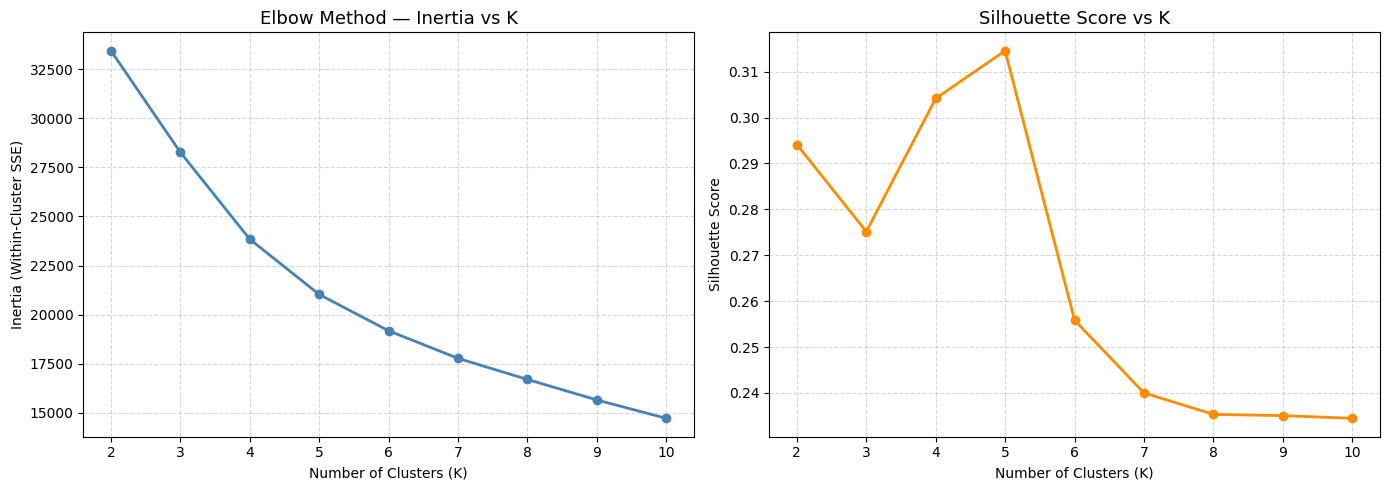


Best K by Silhouette : K=5


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 11)

inertias          = []
silhouette_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, labels, sample_size=5000, random_state=42))
    
    print(f"K={k:2d} | Inertia: {km.inertia_:>12.1f} | Silhouette: {silhouette_score(X_train_scaled, labels, sample_size=5000, random_state=42):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inertias, marker="o", linewidth=2, color="steelblue")
axes[0].set_title("Elbow Method — Inertia vs K", fontsize=13)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (Within-Cluster SSE)")
axes[0].set_xticks(list(K_RANGE))
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(list(K_RANGE), silhouette_scores, marker="o", linewidth=2, color="darkorange")
axes[1].set_title("Silhouette Score vs K", fontsize=13)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(K_RANGE))
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("saved_analysis_states/kmeans_k_selection.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBest K by Silhouette : K={list(K_RANGE)[np.argmax(silhouette_scores)]}")

In [8]:
OPTIMAL_K = 5

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
km_final.fit(X_train_scaled)

print(f"Final K-Means trained with K={OPTIMAL_K}")
print(f"Centroid shape: {km_final.cluster_centers_.shape}")
print(f"\nTrain cluster distribution:")
train_labels = km_final.labels_
unique, counts = np.unique(train_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} customers ({count/len(train_labels)*100:.1f}%)")

val_labels  = km_final.predict(X_val_scaled)
test_labels = km_final.predict(X_test_scaled)

df_train_assigned = df_train[["customer_id"]].copy()
df_train_assigned["cluster"] = train_labels
df_train_assigned["split"]   = "train"

df_val_assigned = df_val[["customer_id"]].copy()
df_val_assigned["cluster"] = val_labels
df_val_assigned["split"]   = "val"

df_test_assigned = df_test[["customer_id"]].copy()
df_test_assigned["cluster"] = test_labels
df_test_assigned["split"]   = "test"

df_assignments = pd.concat([df_train_assigned, df_val_assigned, df_test_assigned], ignore_index=True)

print(f"\nVal cluster distribution:")
unique, counts = np.unique(val_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} customers ({count/len(val_labels)*100:.1f}%)")

print(f"\nTest cluster distribution:")
unique, counts = np.unique(test_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} customers ({count/len(test_labels)*100:.1f}%)")

print(f"\nMaster assignment table shape: {df_assignments.shape}")
print(f"Sample:")
print(df_assignments.head(10))

df_assignments.to_parquet("saved_analysis_states/customer_cluster_assignments.parquet", index=False)
print(f"\nSaved: customer_cluster_assignments.parquet")

Final K-Means trained with K=5
Centroid shape: (5, 17)

Train cluster distribution:
  Cluster 0: 109 customers (3.9%)
  Cluster 1: 943 customers (33.3%)
  Cluster 2: 293 customers (10.4%)
  Cluster 3: 400 customers (14.1%)
  Cluster 4: 1084 customers (38.3%)

Val cluster distribution:
  Cluster 0: 39 customers (4.1%)
  Cluster 1: 336 customers (35.6%)
  Cluster 2: 95 customers (10.1%)
  Cluster 3: 132 customers (14.0%)
  Cluster 4: 341 customers (36.2%)

Test cluster distribution:
  Cluster 0: 31 customers (3.3%)
  Cluster 1: 317 customers (33.6%)
  Cluster 2: 84 customers (8.9%)
  Cluster 3: 159 customers (16.8%)
  Cluster 4: 353 customers (37.4%)

Master assignment table shape: (4716, 3)
Sample:
  customer_id  cluster  split
0     12346.0        1  train
1     12352.0        3  train
2     12353.0        4  train
3     12355.0        4  train
4     12359.0        1  train
5     12361.0        2  train
6     12366.0        4  train
7     12368.0        4  train
8     12369.0        1 

In [9]:
df_test_assignments = df_assignments[df_assignments["split"] == "test"][["customer_id", "cluster"]].copy()

df_eval_test = df_eval[df_eval["customer_id"].isin(test_ids)][
    ["customer_id", "future_revenue", "pred_lightgbm", "pred_rfm", "pred_bgnbd", "pred_pareto"]
].copy()

df_clus = df_eval_test.merge(df_test_assignments, on="customer_id", how="inner")

print(f"Test assignments shape : {df_test_assignments.shape}")
print(f"Eval mart (test) shape : {df_eval_test.shape}")
print(f"df_clus shape          : {df_clus.shape}")

print(f"\nMerge check — any unmatched customers: {df_clus['customer_id'].nunique()} matched out of {len(df_test_assignments)} test assignments")

print(f"\nCluster distribution in df_clus:")
print(df_clus["cluster"].value_counts().sort_index())

print(f"\nNull check:")
print(df_clus.isnull().sum())

print(f"\nSample:")
print(df_clus.head(10).to_string(index=False))

df_clus.to_parquet("saved_analysis_states/df_clus.parquet", index=False)
print(f"\nSaved: df_clus.parquet")

Test assignments shape : (944, 2)
Eval mart (test) shape : (944, 6)
df_clus shape          : (944, 7)

Merge check — any unmatched customers: 944 matched out of 944 test assignments

Cluster distribution in df_clus:
cluster
0     31
1    317
2     84
3    159
4    353
Name: count, dtype: int64

Null check:
customer_id         0
future_revenue      0
pred_lightgbm       0
pred_rfm            0
pred_bgnbd        150
pred_pareto         0
cluster             0
dtype: int64

Sample:
customer_id  future_revenue  pred_lightgbm  pred_rfm  pred_bgnbd  pred_pareto  cluster
    12349.0            0.00     683.849561   2671.14 1450.410845  1431.087433        1
    12350.0            0.00     263.319407    334.40         NaN     0.000000        4
    12351.0            0.00     140.549269    300.93         NaN     0.000000        4
    12356.0          481.46    1750.781897   5826.80 5876.647656  5775.391750        1
    12365.0            0.00     855.808225    641.38         NaN     0.000000    

In [10]:
from scipy import stats

def mae(actual, pred):
    return np.mean(np.abs(actual - pred))

def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred) ** 2))

def top_decile_capture(actual, pred):
    """
    Of the customers actually in the top 10% by revenue,
    what fraction did the model identify in its top 10% predictions?
    """
    n = len(actual)
    if n < 10:
        return np.nan
    top_n = max(1, int(np.ceil(n * 0.10)))
    actual_top = set(np.argsort(actual)[::-1][:top_n])
    pred_top   = set(np.argsort(pred)[::-1][:top_n])
    return len(actual_top & pred_top) / top_n

def spearman(actual, pred):
    if len(actual) < 3:
        return np.nan
    corr, _ = stats.spearmanr(actual, pred)
    return corr

MODELS = {
    "LightGBM" : "pred_lightgbm",
    "RFM"      : "pred_rfm",
    "BG-NBD"   : "pred_bgnbd",
    "Pareto"   : "pred_pareto"
}

actual = df_clus["future_revenue"].values
clusters = sorted(df_clus["cluster"].unique())

results = []

for cluster_id in clusters:
    mask = df_clus["cluster"] == cluster_id
    df_c  = df_clus[mask]
    y     = df_c["future_revenue"].values
    n     = len(df_c)

    for model_name, pred_col in MODELS.items():
        y_hat = df_c[pred_col].values

        results.append({
            "cluster"             : cluster_id,
            "model"               : model_name,
            "n_customers"         : n,
            "mae"                 : mae(y, y_hat),
            "rmse"                : rmse(y, y_hat),
            "top_decile_capture"  : top_decile_capture(y, y_hat),
            "spearman_corr"       : spearman(y, y_hat)
        })

df_results = pd.DataFrame(results)

print("=" * 90)
print("MODEL EVALUATION WITHIN CLUSTERS (Test Customers Only)")
print("=" * 90)

for cluster_id in clusters:
    df_c = df_results[df_results["cluster"] == cluster_id]
    n    = df_c["n_customers"].iloc[0]
    print(f"\nCluster {cluster_id}  |  n={n} customers")
    print("-" * 70)
    print(f"  {'Model':<12} {'MAE':>10} {'RMSE':>12} {'Top-Decile':>12} {'Spearman':>10}")
    print(f"  {'-'*10:<12} {'-'*8:>10} {'-'*10:>12} {'-'*10:>12} {'-'*8:>10}")
    for _, row in df_c.iterrows():
        print(
            f"  {row['model']:<12} "
            f"{row['mae']:>10.2f} "
            f"{row['rmse']:>12.2f} "
            f"{row['top_decile_capture']:>12.3f} "
            f"{row['spearman_corr']:>10.4f}"
        )

# --- Best model per cluster ---
print("\n=== Best Model Per Cluster (by MAE) ===")
best = df_results.loc[df_results.groupby("cluster")["mae"].idxmin()][
    ["cluster", "model", "mae", "rmse", "top_decile_capture", "spearman_corr"]
]
print(best.to_string(index=False))


df_results.to_parquet("saved_analysis_states/model_cluster_results.parquet", index=False)
print(f"\nSaved: model_cluster_results.parquet")

MODEL EVALUATION WITHIN CLUSTERS (Test Customers Only)

Cluster 0  |  n=31 customers
----------------------------------------------------------------------
  Model               MAE         RMSE   Top-Decile   Spearman
  ----------     --------   ----------   ----------   --------
  LightGBM         511.95       764.30        0.500     0.3807
  RFM              348.08       486.62        0.500     0.4111
  BG-NBD              nan          nan        0.000        nan
  Pareto           744.30      1983.75        0.500     0.3512

Cluster 1  |  n=317 customers
----------------------------------------------------------------------
  Model               MAE         RMSE   Top-Decile   Spearman
  ----------     --------   ----------   ----------   --------
  LightGBM         514.54       900.88        0.344     0.5114
  RFM             1781.41      2939.84        0.438     0.4706
  BG-NBD              nan          nan        0.406        nan
  Pareto           767.07      1255.62        0.4